In [1]:
%matplotlib inline

import torch
import seaborn as sns
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from torch import nn, optim
import torchvision
from torch.utils.data import Subset, DataLoader
from torchvision import models, transforms, datasets
import torchvision.transforms.v2 as v2
import matplotlib.pyplot as plt

In [2]:
train_transform = v2.Compose([
        v2.RandomResizedCrop(224, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
        v2.RandomHorizontalFlip(p=0.5),
        v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
        v2.RandomRotation(degrees=10),
        v2.RandomGrayscale(p=0.1),
        v2.ToTensor(),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        v2.RandomErasing(p=0.3, scale=(0.02, 0.1))
    ])

val_transform = v2.Compose([
        v2.Resize(256),
        v2.CenterCrop(224),
        v2.ToTensor(),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/home/a.pozdnyakov/.local/lib/python3.10/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [3]:
def load_data():
    dataset_path = r"simpsons_dataset"
    
    temp_dataset = datasets.ImageFolder(root=dataset_path)
    
    train_idx, val_idx = train_test_split(
        range(len(temp_dataset)),
        test_size=0.2,
        stratify=temp_dataset.targets,
        random_state=42
    )

    train_dataset = datasets.ImageFolder(root=dataset_path, transform=train_transform)
    val_dataset = datasets.ImageFolder(root=dataset_path, transform=val_transform)

    train_dataset = Subset(train_dataset, train_idx)
    val_dataset = Subset(val_dataset, val_idx)

    kwargs = {'num_workers': 2, 'persistent_workers':True, 'pin_memory': True} if device.type == 'cuda' else {}

    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, **kwargs)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False ,**kwargs)

    return temp_dataset.classes, len(temp_dataset.classes), train_loader, val_loader

In [4]:
def preparing_model(num_classes):
    model = torchvision.models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    new_fc = nn.Linear(model.fc.in_features, num_classes)

    model.fc = new_fc

    for param in model.parameters():
        param.requires_grad = False

    for param in model.layer4.parameters():
        param.requires_grad = True

    for param in model.fc.parameters():
        param.requires_grad = True
    
    return model.to(device)

In [5]:
def train(train_loader, val_loader, criterion, optimizer, model):
    epochs = 30
    best_val_acc = 0
    patience_counter = 0
    best_val_loss = float('inf')

    array_epochs = []
    array_train_loss = []
    array_val_loss = []
    
    for epoch in range(epochs):
        array_epochs.append(epoch)
        model.train()
        train_loss = 0
        for x_train, y_train in train_loader:
            x_train, y_train = x_train.to(device, non_blocking=True), y_train.to(device, non_blocking=True)
            optimizer.zero_grad()
            output = model(x_train)

            loss = criterion(output, y_train)
            loss.backward()
            optimizer.step()
            train_loss+=loss.item()

        train_loss /= len(train_loader)
        array_train_loss.append(train_loss)
        
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for x_val, y_val in val_loader:
                x_val, y_val = x_val.to(device, non_blocking=True), y_val.to(device, non_blocking=True)

                outputs = model(x_val)
                loss = criterion(outputs, y_val)
                val_loss += loss.item()

                predicted = outputs.argmax(dim=1)
                total += x_val.size(0)
                correct += (predicted == y_val).sum().item()

        val_loss /= len(val_loader)
        array_val_loss.append(val_loss)
        val_acc = 100 * correct / total

        print(f"Epoch {epoch + 1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.2f}% | "
              f"Best: {best_val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_loss = val_loss
            best_val_acc = val_acc
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
            }, 'best_model.pth')
            print(f"модель обновлена точность: {val_acc:.2f}%")
        else:
            patience_counter += 1
            if patience_counter >= 5:
                print(f"\nранняя остановка на эпохе {epoch + 1}")
                break

    print(f"\nлучшая валидационная точность: {best_val_acc:.2f}%")

    return array_epochs, array_train_loss, array_val_loss

In [6]:
def train_graph(epochs, train_loss, val_loss):
    plt.figure(figsize=(10,5))

    plt.plot(epochs, train_loss, color="green", label="train loss")
    plt.plot(epochs, val_loss, color="yellow", label="val loss")

    plt.xlabel("эпоха")
    plt.ylabel("loss")
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

In [7]:
def test(val_loader, model, class_names):
    checkpoint = torch.load('best_model.pth')
    model.load_state_dict(checkpoint['model_state_dict'])

    model.eval()
    all_preds, all_labels = [], []
    correct_examples = []
    incorrect_examples = []
    
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val, y_val = x_val.to(device, non_blocking=True), y_val.to(device, non_blocking=True)
            outputs = model(x_val)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_val.cpu().numpy())

            for i in range(len(x_val)):
                img = x_val[i].cpu()
                true_label = y_val[i].item()
                pred_label = preds[i].item()
                conf = probs[i, pred_label].item()

                example = {
                    'image': img,
                    'true_label': true_label,
                    'pred_label': pred_label,
                    'true_name': class_names[true_label],
                    'pred_name': class_names[pred_label],
                    'confidence': conf
                    }
                
                if true_label == pred_label:
                    correct_examples.append(example)
                else:
                    incorrect_examples.append(example)

    print(f"Macro F1-score: {100 * f1_score(all_labels, all_preds, average='macro'):.2f}%")

    return all_preds, all_labels, correct_examples, incorrect_examples

In [8]:
def create_conf_mat(class_names, all_labels, all_preds):
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(16, 14))  # Большой размер для 20 классов

    sns.heatmap(
        cm, 
        annot=True,           # Показывать числа в ячейках
        fmt='d',              # Формат: целые числа (количества)
        cmap='Blues',         # Цветовая схема
        xticklabels=class_names, 
        yticklabels=class_names,
        cbar_kws={'label': 'Количество'}  # Подпись к цветовой шкале
    )
    
    plt.xlabel('Предсказанный класс', fontsize=12, fontweight='bold')
    plt.ylabel('Истинный класс', fontsize=12, fontweight='bold')
    plt.title('Матрица ошибок — 20 классов (Simpsons Dataset)', fontsize=14, fontweight='bold', pad=20)
    
    # Поворот подписей для читаемости
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    
    plt.tight_layout()
    # plt.savefig('confusion_matrix_counts.png', dpi=300, bbox_inches='tight')  # Сохранение
    # plt.show()

In [9]:
def show_img(correct_examples, incorrect_examples):
    
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    
    def denormalize(img_tensor):
        img = inv_normalize(img_tensor)
        img = img.permute(1, 2, 0).clamp(0, 1).cpu().numpy()
        return img
    
    if len(correct_examples) > 0:
        fig, axes = plt.subplots(2, 5, figsize=(20, 4))
        fig.suptitle('Корректные предсказания', fontsize=16, fontweight='bold', y=1.02)
        axes = axes.ravel()

        for idx, ax in enumerate(axes):
            if idx < len(correct_examples):
                ex = correct_examples[idx]
                img = denormalize(ex['image'])
                ax.imshow(img)
                ax.set_title(f"{ex['true_name']}\nConf: {ex['confidence']:.1%}", 
                            fontsize=10, color='green', fontweight='bold')
            ax.axis('off')
        
        plt.tight_layout()
        # plt.savefig('correct_predictions.png', dpi=300, bbox_inches='tight')
        # plt.show()
    
    if len(incorrect_examples) > 0:
        fig, axes = plt.subplots(2, 5, figsize=(20, 4))
        fig.suptitle('Ошибки классификации', fontsize=16, fontweight='bold', y=1.02)
        axes = axes.ravel()
        
        for idx, ax in enumerate(axes):
            if idx < len(incorrect_examples):
                ex = incorrect_examples[idx]
                img = denormalize(ex['image'])
                ax.imshow(img)
                ax.set_title(f"True: {ex['true_name']}\nPred: {ex['pred_name']}\nConf: {ex['confidence']:.1%}", 
                            fontsize=9, color='red', fontweight='bold')
            ax.axis('off')

        plt.tight_layout()
        # plt.savefig('incorrect_predictions.png', dpi=300, bbox_inches='tight')
        # plt.show()

In [10]:
def main():
    class_names, num_classes, train_loader, val_loader = load_data()
    model = preparing_model(num_classes)

    criterion = nn.CrossEntropyLoss().to(device)
    optimizer = optim.AdamW(list(model.fc.parameters()) + list(model.layer4.parameters()), lr=0.001, weight_decay=1e-4)

    epochs, train_loss, val_loss = train(train_loader, val_loader, criterion, optimizer, model)

    train_graph(epochs, train_loss, val_loss)

    all_predicts, all_labels, correct_ex, incorrect_ex = test(val_loader, model, class_names)

    create_conf_mat(class_names, all_labels, all_predicts)

    show_img(correct_ex, incorrect_ex)

Epoch 1/30 | Train Loss: 0.5472 | Val Loss: 0.2596 | Val Acc: 93.20% | Best: 0.00%
модель обновлена точность: 93.20%
Epoch 2/30 | Train Loss: 0.2266 | Val Loss: 0.2379 | Val Acc: 93.84% | Best: 93.20%
модель обновлена точность: 93.84%
Epoch 3/30 | Train Loss: 0.1716 | Val Loss: 0.1967 | Val Acc: 94.73% | Best: 93.84%
модель обновлена точность: 94.73%
Epoch 4/30 | Train Loss: 0.1306 | Val Loss: 0.1811 | Val Acc: 95.04% | Best: 94.73%
модель обновлена точность: 95.04%
Epoch 5/30 | Train Loss: 0.1140 | Val Loss: 0.2044 | Val Acc: 94.73% | Best: 95.04%
Epoch 6/30 | Train Loss: 0.0989 | Val Loss: 0.1905 | Val Acc: 95.24% | Best: 95.04%
модель обновлена точность: 95.24%
Epoch 7/30 | Train Loss: 0.0928 | Val Loss: 0.2029 | Val Acc: 95.06% | Best: 95.24%
Epoch 8/30 | Train Loss: 0.0738 | Val Loss: 0.1843 | Val Acc: 95.47% | Best: 95.24%
модель обновлена точность: 95.47%
Epoch 9/30 | Train Loss: 0.0711 | Val Loss: 0.1869 | Val Acc: 95.35% | Best: 95.47%
Epoch 10/30 | Train Loss: 0.0614 | Val Lo

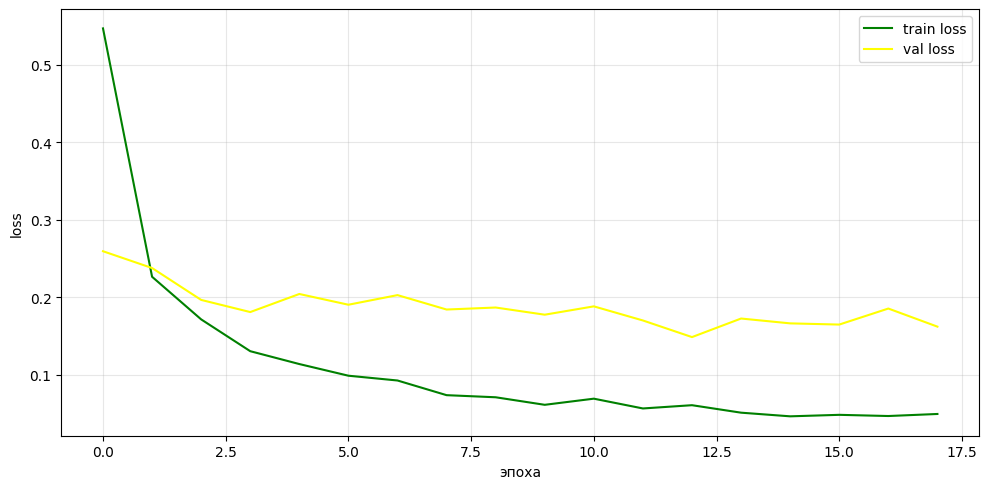

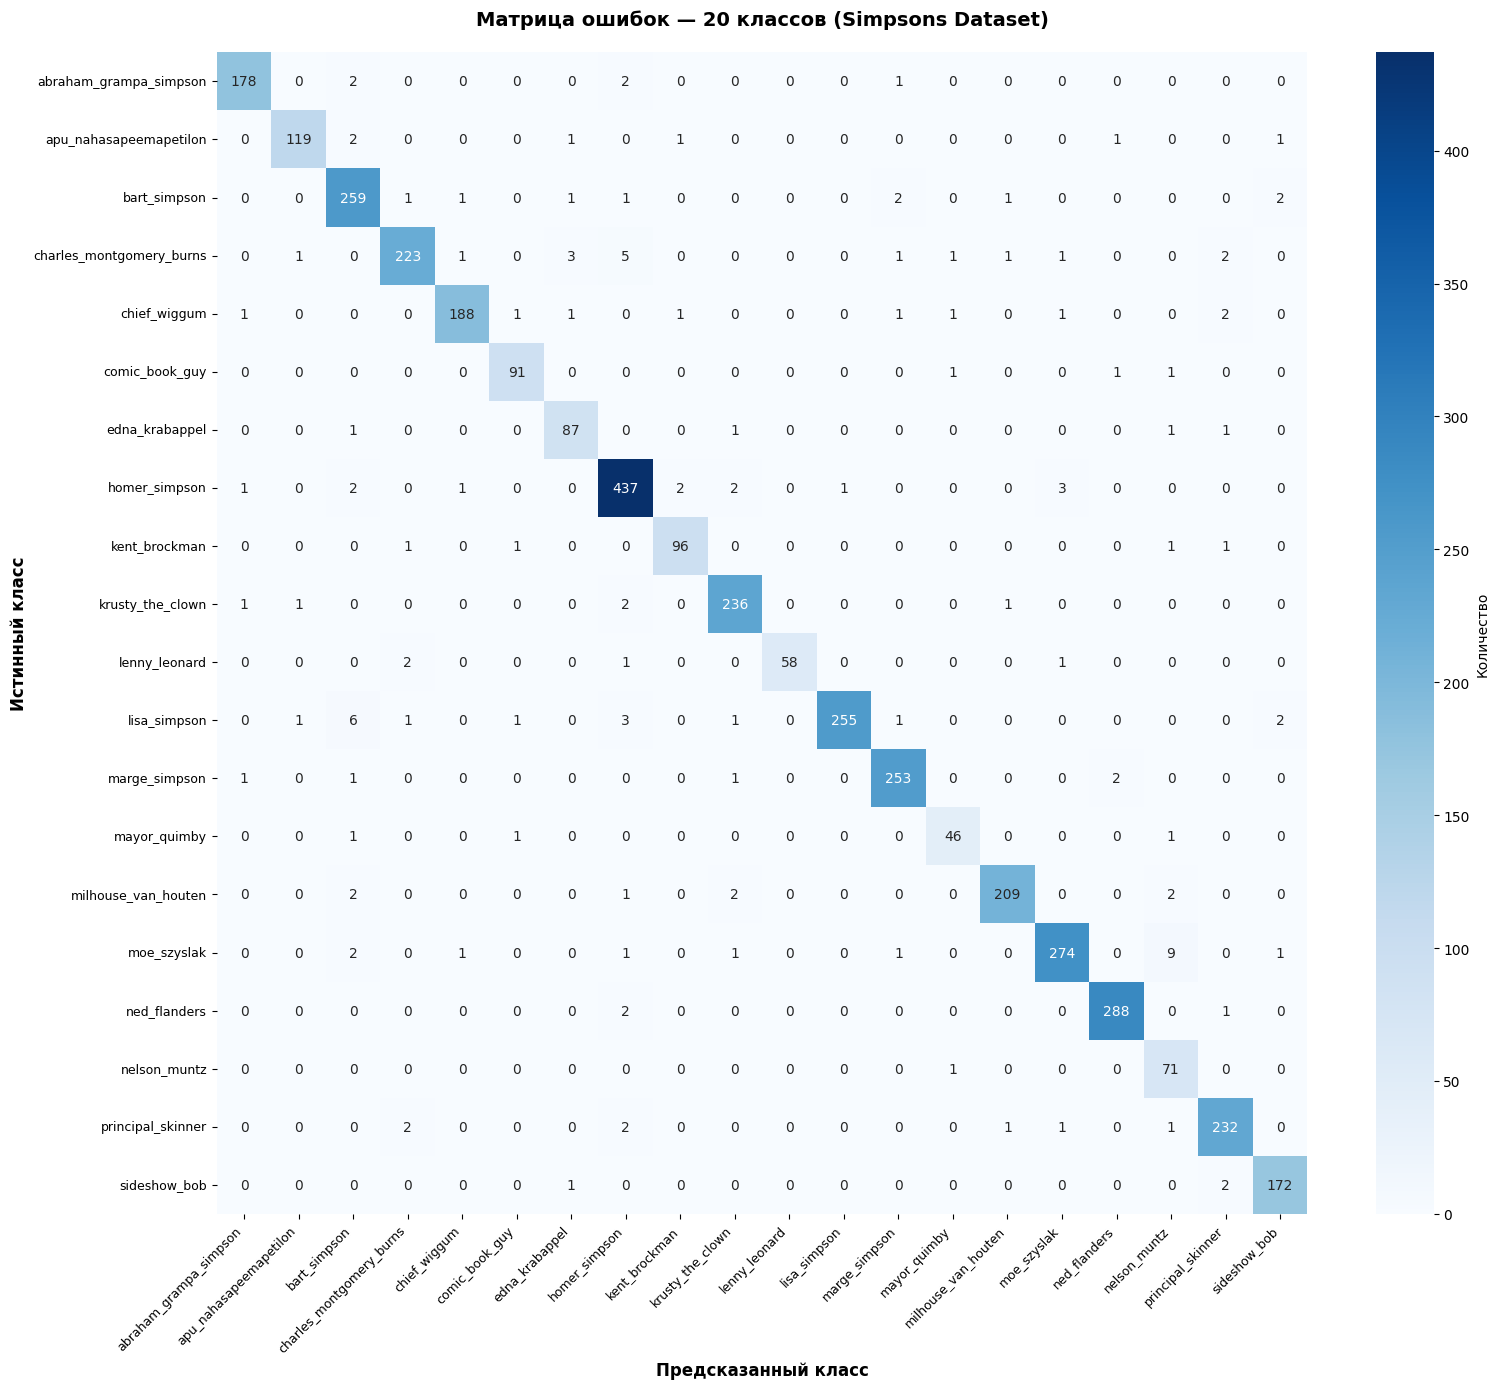

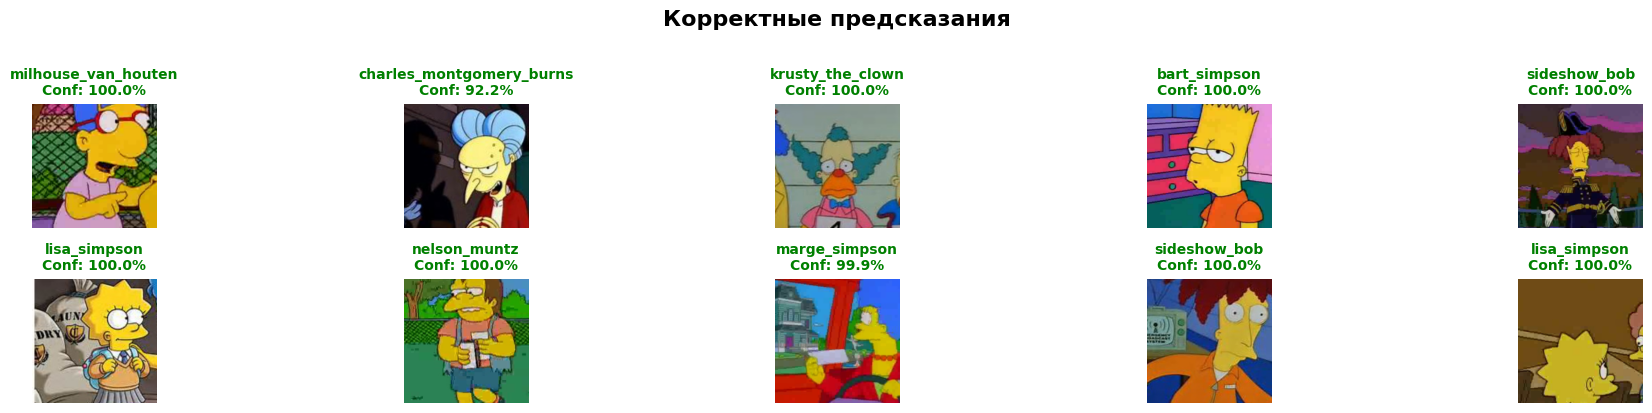

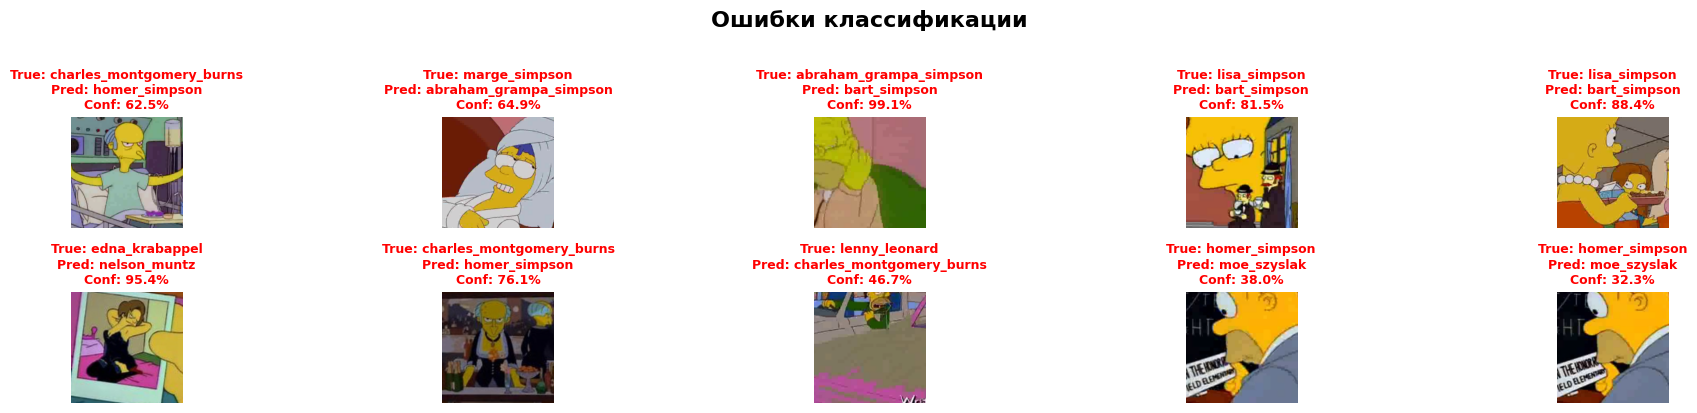

In [11]:
if __name__ == '__main__':
    main()